<a href="https://colab.research.google.com/github/Luis-Hernan-Antonio-Crisostomo/Investigaci-n-de-operaciones-/blob/main/Tutorial_NetworkX_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#<font color="green">**Tutorial NetworkX 1**
*Elaboró: Antonio Crisostomo Luis Hernán*


En este cuaderno se describe la solución de tres problemas de redes:

*   **Árbol de expasión mínima**
*   **Ruta más corta**
*   **Flujo máximo**

Este tutorial esta basado en la documentación de: https://networkx.org/en/

In [104]:
import networkx as nx #Importa la librería networkx y le asigna el alias nx
import matplotlib.pyplot as plt #Importa el módulo pyplot de la librería Matplotlib, para personalizar los gráficos

##<font color="Darkblue">**Árbol de expansión mínima**


$\underline{\text{ALGORITMO}}$

Sea N = {1,2,3,... n} el conjunto de nodos de la red

Definimos:

$$
C_k = \text{{Conjunto de nodos conectados de forma permanente en la iteración k}}
\\
\hat{C}_k=\text{{Conjunto de nodos que todavía no se han conectado}}
$$
**Paso 0:** $C_0 = 0 ; \hat{C}_0$ = N

**Paso 1:** Comenzar con cualquier nodo en $\hat{C}_0$ y hacer $C_1$ = {i} $$\hat{C}_1 = N - {i}$$
$$\text{Hacer k = 2} $$

**Paso general k:** Seleccionar un nodo <font color="green">j*</font> en el conjunto no conectado <font color="green">$\hat{C}_{k-1}$</font> que produzca el <font color="green"> **arco más corto** </font> a un nodo conectado en el conjunto <font color="green">$C_{k-1}$</font>

Enlazar a <font color="green">j*</font> en forma permanente con <font color="green">$C_{k-1}$</font> y sacarlo de <font color="green">$\hat{C}_{k-1}$</font>, es decir:

<font color="green">$C_{k} = C_{k-1}$ + {j*} ; $\hat{C}_{k-1}$ - {j*}</font>

Detener cuando <font color="green">$\hat{C}_k = 0$</font>






**EJEMPLO**

Considere la siguiente red y calcule el árbol de expansión mínima

<img src="https://lh3.googleusercontent.com/d/1_uI_NJfi5WPA7TvKVY9fFv38ym5PBYAx" width=400>

$$\text{Solución}$$
A continuación se describe el código para dibujar la red y apartir de ésta obtener el **árbol de expansión mínima**. (Se considera la red no dirigida)

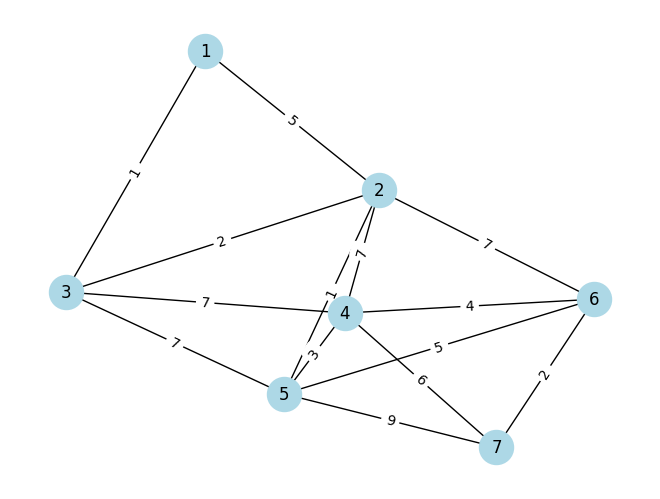

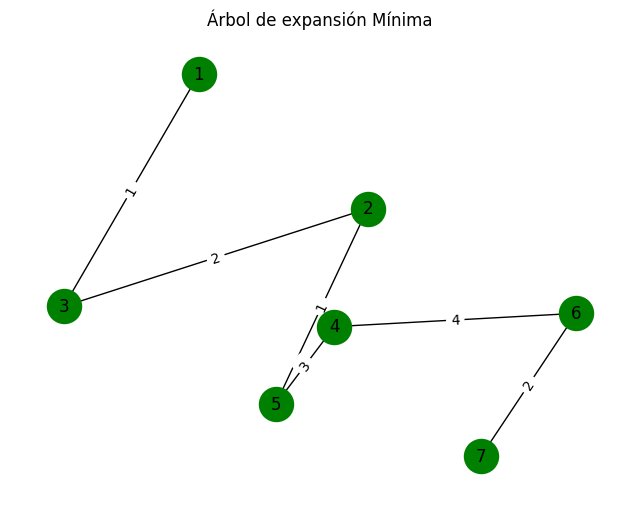

Distancia =  13.0


In [105]:
G = nx.Graph()
#Agregamos los nodos, arcos y sus distancias con el formato (nodoA,nodoB,Distancia)
G.add_weighted_edges_from([(1,2,5),(1,3,1),(2,5,1),(2,4,7),(2,6,6),(3,2,2),(3,5,7),
    (3,4,6),(4,3,7),(4,6,4),(4,7,6),(5,4,3),(5,6,5),(5,7,9),(6,2,7),(6,7,2)])
pos=nx.spring_layout(G,seed=42) #Fija la posición de los nodos
edge_labels=nx.get_edge_attributes(G,'weight') #Extrae los valores de las distancias
nx.draw(G,pos, with_labels=True, node_color="lightblue",node_size=600)#Dibuja la red y los nodos, dibuja los nodos de color azul claro
nx.draw_networkx_edge_labels(G,pos,edge_labels=edge_labels)#Etiqueta las distancias en los arcos
arbol=nx.minimum_spanning_tree(G,algorithm='kruskal')#Determina el árbol de expansión minima y lo asigna a arbol
edge_labels_mst=nx.get_edge_attributes(arbol,'weight') #Extrae los valores de las distancias del árbol de expansión
plt.figure(figsize=(8,6)) #Abre una nueva ventana de dimension axb (a,b)
plt.title("Árbol de expansión Mínima")#Agrega titulo a la ventana
nx.draw(arbol,pos, with_labels=True, node_color="green",node_size=600)#Dibuja la red y los nodos del arbol, asigna el color verde a los nodos y tamaño de 600
nx.draw_networkx_edge_labels(arbol,pos,edge_labels=edge_labels_mst)#Etiqueta las distancias en los arcos del arbol
distancia_total = arbol.size(weight='weight') #Calcula la distancia del árbol y la asigna a distancia_total
plt.show() #Muestra una ventana con el arbol de expansión mínima
print("Distancia = ",distancia_total)#Imprime el valor de la distancia recorrida en el árbol

##<font color="Darkblue">**Ruta más corta**

Considerando dos nodos especiales <font color="blue">Origen</font> y <font color="blue">Destino</font> el objetivo es encontrar la ruta más corta *-la trayectoria de mínima distancia total-* del <font color="blue">Origen</font> al <font color="blue">Destino</font>.

$\underline{\text{ALGORITMO}}$

<font color="Green">**Objetivo de la n-ésima iteración:**</font> Encontrar el n-ésimo nodo más cercano al **origen**. Repetir para n=1,2,3,... hasta que el n-ésimo nodo más cercado sea el **destino**.

<font color="Green">**Datos de la n-ésima iteración:**</font> n-1 nodos más cercanos al **origen** *-encontrados en iteracionesprevias'*, incluída su ruta más corta y la distancia desde el **origen** (estos son <font color="Green">nodos no resueltos</font>).

<font color="Green">**Candidato a n-ésimo nodo más cercano:**</font> Cada nodo no resuelto con conexión directa a uno o más nodos resueltos. Tomar el nodo no resuelto que tiene la ligadura más corta (los empates proporcionan candidatos adicionales).

<font color="Green">**Cálculo del n-ésimo nodo más cercano:**</font> Para cada nodo resuelto y sus candidatos, se suma la distancia entre ellos y la ruta más corta desde el origen a este nodo resuelto. El candidato con la distancia total más pequeña en el n-ésimo nodo más cercano *-los empates proporcionan nodos resueltos adicionales y su ruta más corta es la que genera esta diatancia-.*


**EJEMPLO**

Consideremos la red del ejemplo anterior:

<img src="https://lh3.googleusercontent.com/d/1_uI_NJfi5WPA7TvKVY9fFv38ym5PBYAx" width=400>

$$\text{Solución}$$
A continuación se describe el código para dibujar la red y determinar apartir de ésta **la ruta más corta**. (Se considera la red dirigida)

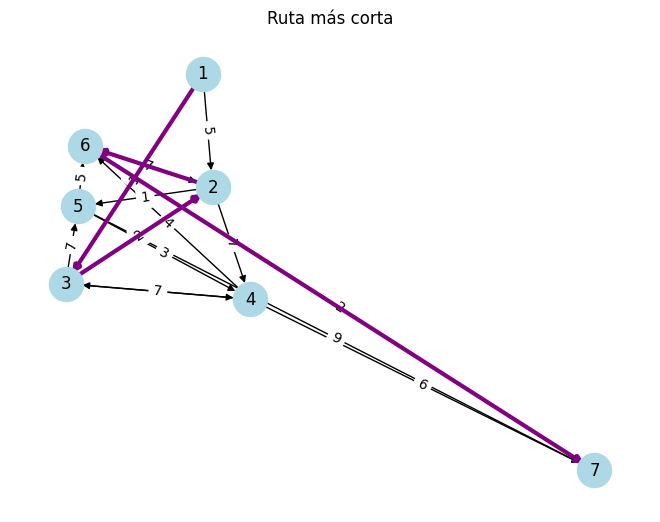

Distancia mínima =  11


In [106]:
G = nx.DiGraph()
#Agregamos los nodos, arcos y sus distancias con el formato (nodoA,nodoB,Distancia)
G.add_weighted_edges_from([(1,2,5),(1,3,1),(2,5,1),(2,4,7),(2,6,6),(3,2,2),(3,5,7),
    (3,4,6),(4,3,7),(4,6,4),(4,7,6),(5,4,3),(5,6,5),(5,7,9),(6,2,7),(6,7,2)])
origen=1 #Definimos al nodo 1 como el origen
destino=7 #Definimos al nodo 7 como el destino
ruta_mas_corta = nx.shortest_path(G, source=origen, target=destino, weight='weight')#Calculamos la ruta más corta de la red G utilizando la función shortest_path
distancia=nx.shortest_path_length(G, source=origen, target=destino, weight='weight')#Calculamos la ditancia de la ruta más corta con la función shortest_path_length
pos=nx.spring_layout(G,seed=42) #Fija la posición de los nodos
edge_labels=nx.get_edge_attributes(G,'weight') #Extrae los valores de las distancias
nx.draw(G,pos, with_labels=True, node_color="lightblue",node_size=600)#Dibuja la red, los nodos y los arcos (los nodos serán de color azul claro)
nx.draw_networkx_edge_labels(G,pos,edge_labels=edge_labels)#Etiqueta las distancias en los arcos
pares_de_nodos = list(zip(ruta_mas_corta[:-1], ruta_mas_corta[1:]))#Crea una lista con los pares de nodos en la ruta más corta, zip junta los elementos, [1:] descarta el primer nodo y [:-1] descarta el último nodo
nx.draw_networkx_edges(G, pos, edgelist=pares_de_nodos, edge_color="purple",width=3) #Dibuja los arcos en rojo de la ruta más corta
plt.title("Ruta más corta")#Agrega título a la ventana
plt.show()
print("Distancia mínima = ", distancia)


$\text{Por lo tanto la ruta más corta es:}$
$$1\to3\to2\to6\to7$$
$\text{La distancia mínima es: 11}$

##<font color="Darkblue">**Flujo Máximo**
**Definiciones**

**Red residual**: es la red que muestra las capacidades <font color="green">restantes</font>, llamadas <font color="green">capacidades residuales</font>, para asignar flujos <font color="green">adicionales</font>.

**Trayectoria de aumento**: Trayectoria dirigida del **Origen** al **Destino** en la red residual, tal que <font color="green">todos</font> sus arcos tienen capacidad residual <font color="green">estrictamente positiva</font> el <font color="green">mínimo</font> de estas capacidades se llama <font color="green">capacidad residual de la trayectoria de aumento</font>.

$\underline{\text{ALGORITMO}}$

**1.-** Identificar una trayectoria de aumento (si no existe una, los flujos netos asignados constituyen un patrón de flujo óptimo).

**2.-** Identificar la capacidad residual <font color="green">c*</font> de esta trayectoria. Se aumenta en <font color="green">c*</font> el flujo de esta trayectoria.

**3.-** Se <font color="green">disminuye en c*</font> la capacidad residual de cada arco en esta trayectoria de aumento. Se aumenta en <font color="green">c*</font> la capacidad residual de cada arco en la direcciónn opuesta en esta trayectoria.

*Regresar al **paso 1***

**EJEMPLO**

Consideremos la red

<img src="https://lh3.googleusercontent.com/d/1RWiXg1HfjW-ic1PHcfCBBB8Nk71tj6a9" width=400>

$$\text{Solución}$$
A continuación se describe el código para obtener el **flujo máximo de la red**

In [107]:
G = nx.DiGraph()#Creamos el gráfico dirigido
#Agregamos los nodos, arcos y su capacidades (nodoA,nodoB,Capacidad)
G.add_edge(1,3,capacity=14.0)
G.add_edge(1,5,capacity=4.0)
G.add_edge(1,2,capacity=8.0)
G.add_edge(2,3,capacity=5.0)
G.add_edge(2,5,capacity=6.0)
G.add_edge(2,4,capacity=7.0)
G.add_edge(3,2,capacity=10.0)
G.add_edge(3,4,capacity=9.0)
G.add_edge(3,5,capacity=10.0)
G.add_edge(4,2,capacity=6.0)
G.add_edge(4,3,capacity=7.0)
G.add_edge(4,5,capacity=5.0)
flujo_maximo, flujo_por_arco = nx.maximum_flow(G,1,5)#Calculamos el flujo máximo de la red G desde el nodo 1 al nodo 5 utilizando la función maximum_flow
print(flujo_maximo) #imprime el flujo máximo
print(flujo_por_arco) #Imprime el flujo maximo en cada arco a partir de un nodo

25.0
{1: {3: 13.0, 5: 4.0, 2: 8.0}, 3: {2: 0, 4: 5.0, 5: 10.0}, 5: {}, 2: {3: 2.0, 5: 6.0, 4: 0}, 4: {2: 0, 3: 0, 5: 5.0}}


Por lo tanto el flujo máximo en esta red es de **25 unidades**.